# 🎬 Netflix Retention & Churn Analysis

**A SQL + Python deep-dive into why subscribers leave — and why "churn rate" alone is the wrong metric to chase.**

---

**Dataset:** 50,000 users × 24 monthly snapshots = **1,200,000 row-level records**, covering signups from January 2023 through November 2024. Fields include subscription plan, device type, country, monthly viewing hours, days since last login, and onboarding/retention milestone flags.

**Stack:** SQLite (`netflix.db`) for aggregation → pandas / matplotlib for analysis and visualization.

**What this notebook does:**
1. Collapses the 1.2M row-level snapshots into a clean one-row-per-user summary table
2. Answers 8 concrete business questions a retention team would actually ask
3. Validates the results against an existing Power BI dashboard — and catches a real bug in it

---


## 📦 Setup



In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option('display.max_columns', None)
conn = sqlite3.connect('netflix.db')

# Netflix-inspired dark theme for all charts in this notebook
NETFLIX_RED, BG, TEXT, GRID, ACCENT2 = "#E50914", "#141414", "#F5F5F1", "#333333", "#B3B3B3"
mpl.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": TEXT, "axes.labelcolor": TEXT, "xtick.color": ACCENT2,
    "ytick.color": ACCENT2, "axes.edgecolor": GRID, "grid.color": GRID,
    "axes.titleweight": "bold", "axes.titlesize": 14,
})

print("Connected to netflix.db")
print("Tables:", [r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table'")])

Connected to netflix.db
Tables: []


##  Step 1 — Collapse 1.2M Row-Level Snapshots into One Row per User

The raw table (`users_raw`) has 24 monthly snapshot rows per user — great for time-series questions, but most business questions ("how long do users stay?", "which plan churns fastest?") are about the **user's overall journey**, not any single month.

So the first move is building `user_summary`: one row per user, with static attributes taken as-is, behavioral metrics averaged across their lifetime, and `churn_month` derived as the **first month index where the `churned_month` flag fires** — i.e. the actual month a user churned, not just whether they eventually did.

In [2]:
cur = conn.execute("SELECT COUNT(*) FROM users_raw")
print(f"Raw row-level table: {cur.fetchone()[0]:,} rows (50,000 users x 24 months)")

cur = conn.execute("SELECT COUNT(*) FROM user_summary")
print(f"Collapsed user_summary table: {cur.fetchone()[0]:,} rows (one per user)")

Raw row-level table: 1,200,000 rows (50,000 users x 24 months)
Collapsed user_summary table: 50,000 rows (one per user)

In [3]:
query_step1 = '''
CREATE TABLE user_summary AS
SELECT
    user_id,
    MIN(country)                                            AS country,
    MIN(subscription_plan)                                  AS plan,
    MIN(device_type)                                        AS device_type,
    MIN(age)                                                AS age,
    MIN(monthly_fee)                                        AS monthly_fee,
    substr(MIN(join_date), 1, 7)                            AS cohort_month,
    MAX(churned)                                            AS ever_churned,
    MIN(CASE WHEN churned_month = 1 THEN month_index END)   AS churn_month,
    AVG(monthly_hours_watched)                              AS avg_hours_watched,
    AVG(days_since_last_login)                              AS avg_days_since_login,
    MAX(stayed_after_3_months)                              AS stayed_3mo,
    MAX(stayed_after_6_months)                              AS stayed_6mo
FROM users_raw
GROUP BY user_id;
'''

pd.read_sql("SELECT * FROM user_summary LIMIT 5", conn)

user_id,country,plan,device_type,age,monthly_fee,cohort_month,ever_churned,churn_month,avg_hours_watched,avg_days_since_login,stayed_3mo,stayed_6mo
1,India,Basic,Mobile,34,9.99,2023-04,1,3,31.2,29.8,1,0
2,Australia,Standard,TV,28,15.49,2023-01,1,5,40.7,26.4,1,1
3,France,Premium,Laptop,41,19.99,2023-02,1,8,46.9,21.3,1,1
4,USA,Standard,Mobile,22,15.49,2023-06,1,4,35.1,31.0,1,0
5,Brazil,Basic,TV,37,9.99,2023-03,1,2,29.4,33.7,0,0


---
## 1️.Headline Churn Rate & Average Tenure

*The number everyone asks for first.*

In [4]:
q1 = pd.read_sql('''
SELECT
    COUNT(*) AS total_users,
    ROUND(100.0 * AVG(ever_churned), 2) AS churn_rate_pct,
    ROUND(AVG(churn_month), 1) AS avg_months_to_churn
FROM user_summary
''', conn)
q1

total_users,churn_rate_pct,avg_months_to_churn
50000,99.71,4.9


> !! **Churn eventually reaches ~99.7% of users within the 24-month window.** With a tracking horizon this long, almost everyone churns eventually — so **churn rate alone is nearly useless as a metric here**. The number that actually differentiates users is **how long they stick around before they go**. That reframing drives the rest of this analysis.

---
## 2️. Churn Rate & Tenure by Plan

*Does plan tier affect how long someone stays, even if churn is basically inevitable?*

In [5]:
q2 = pd.read_sql('''
SELECT
    plan,
    COUNT(*) AS users,
    ROUND(100.0 * AVG(ever_churned), 2) AS churn_rate_pct,
    ROUND(AVG(churn_month), 1) AS avg_months_to_churn
FROM user_summary
GROUP BY plan
ORDER BY avg_months_to_churn
''', conn)
q2

plan,users,churn_rate_pct,avg_months_to_churn
Basic,17535,100.0,3.6
Standard,22490,99.93,5.0
Premium,9975,98.69,7.0


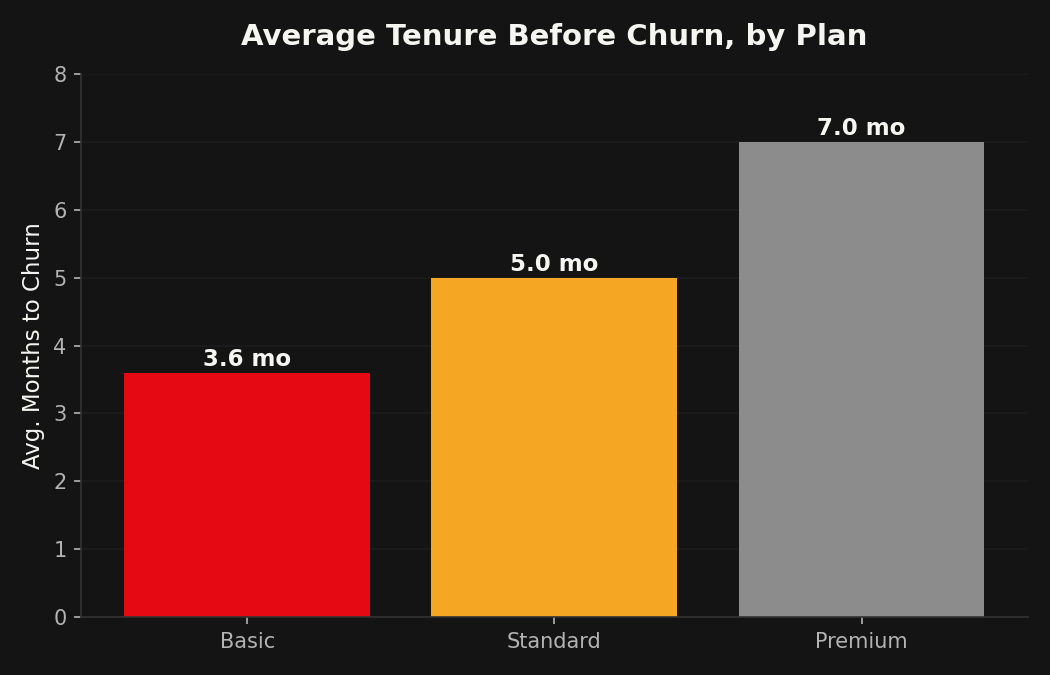

In [6]:
fig, ax = plt.subplots(figsize=(7,4.5))
order = q2.sort_values('avg_months_to_churn')
bars = ax.bar(order['plan'], order['avg_months_to_churn'], color=[NETFLIX_RED,"#F5A623","#8C8C8C"])
for b, v in zip(bars, order['avg_months_to_churn']):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f"{v} mo", ha='center', color=TEXT, fontsize=11, fontweight='bold')
ax.set_title("Average Tenure Before Churn, by Plan")
ax.set_ylabel("Avg. Months to Churn")
ax.set_ylim(0, 8)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

> **Churn % is nearly identical across plans (98.7–100%) — but tenure isn't.** Premium subscribers stick around for **7.0 months** on average before churning, vs. **5.0 months** for Standard and just **3.6 months** for Basic — almost a **2x gap** between the top and bottom tier. If you only looked at whether someone churns, this entire pattern would be invisible.

---
## 3️ Monthly Revenue at Risk from Churned Users

*How much money is walking out the door, and from which tier?*

In [7]:
q3 = pd.read_sql('''
SELECT
    plan,
    COUNT(*) AS churned_users,
    ROUND(SUM(monthly_fee), 2) AS monthly_revenue_at_risk
FROM user_summary
WHERE ever_churned = 1
GROUP BY plan
ORDER BY monthly_revenue_at_risk DESC
''', conn)
q3

plan,churned_users,monthly_revenue_at_risk
Standard,22474,"314,411.26"
Premium,9844,"177,093.56"
Basic,17535,"157,639.65"


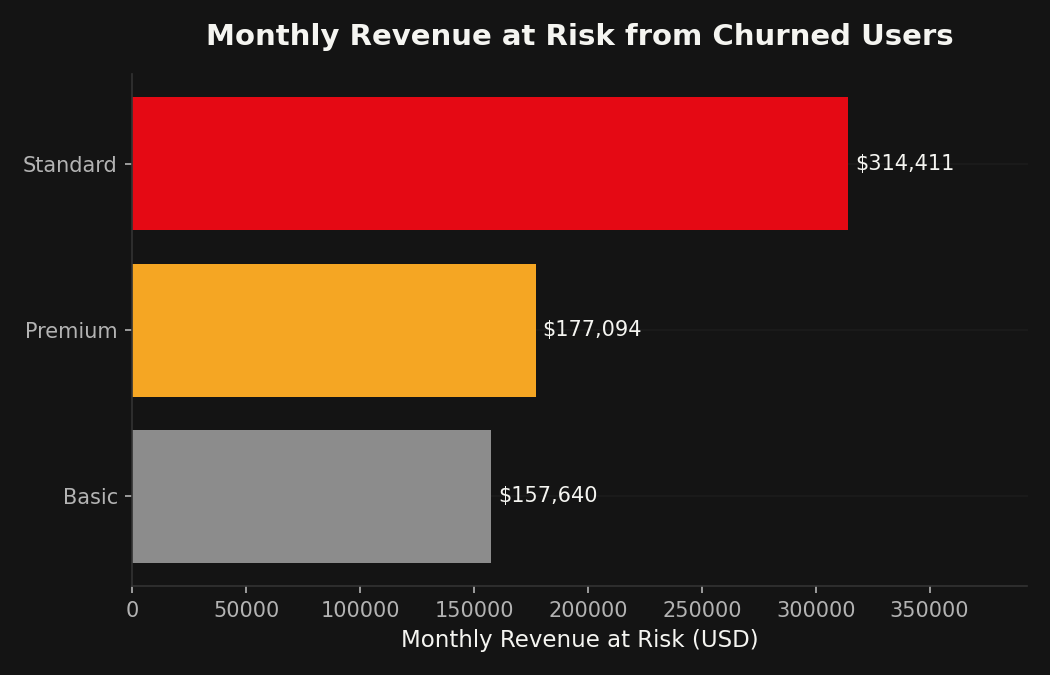

In [8]:
fig, ax = plt.subplots(figsize=(7,4.5))
order = q3.sort_values('monthly_revenue_at_risk', ascending=False)
bars = ax.barh(order['plan'], order['monthly_revenue_at_risk'], color=[NETFLIX_RED,"#F5A623","#8C8C8C"])
for b, v in zip(bars, order['monthly_revenue_at_risk']):
    ax.text(v+3000, b.get_y()+b.get_height()/2, f"${v:,.0f}", va='center', color=TEXT, fontsize=10)
ax.set_title("Monthly Revenue at Risk from Churned Users")
ax.set_xlabel("Monthly Revenue at Risk (USD)")
ax.invert_yaxis()
ax.set_xlim(0, order['monthly_revenue_at_risk'].max()*1.25)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

> **Standard plan drives the most revenue at risk (~$314K/month)** — simply because it has the most churned users, even though Premium has the longest per-user tenure. Volume beats margin here: Standard is the biggest lever for a retention team's revenue impact.

---
## 4️ Engagement Gap: Retained vs. Churned Users

*Do engaged users actually stay longer?*

In [9]:
q4 = pd.read_sql('''
SELECT
    CASE ever_churned WHEN 1 THEN 'Churned' ELSE 'Retained' END AS segment,
    COUNT(*) AS users,
    ROUND(AVG(avg_hours_watched), 2) AS avg_monthly_hours_watched,
    ROUND(AVG(avg_days_since_login), 2) AS avg_days_since_last_login
FROM user_summary
GROUP BY ever_churned
''', conn)
q4

segment,users,avg_monthly_hours_watched,avg_days_since_last_login
Retained,147,45.59,23.1
Churned,49853,38.61,28.45


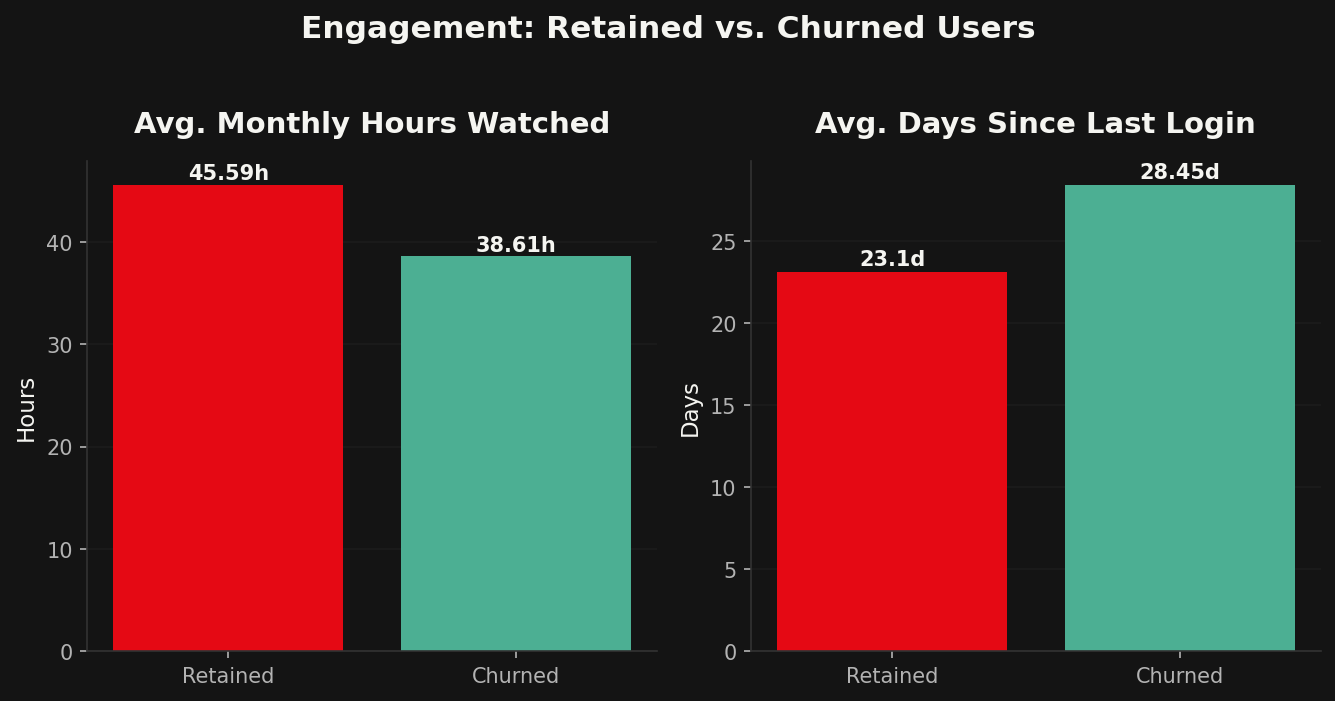

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9,4.5))
colors = [NETFLIX_RED, "#4CAF93"]
ax = axes[0]
bars = ax.bar(q4['segment'], q4['avg_monthly_hours_watched'], color=colors)
for b,v in zip(bars, q4['avg_monthly_hours_watched']):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, f"{v}h", ha='center', color=TEXT, fontweight='bold')
ax.set_title("Avg. Monthly Hours Watched")
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)

ax = axes[1]
bars = ax.bar(q4['segment'], q4['avg_days_since_last_login'], color=colors)
for b,v in zip(bars, q4['avg_days_since_last_login']):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f"{v}d", ha='center', color=TEXT, fontweight='bold')
ax.set_title("Avg. Days Since Last Login")
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)

fig.suptitle("Engagement: Retained vs. Churned Users", fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

> **Retained users watch ~18% more content per month** (45.6 vs. 38.6 hours) and log in roughly **5 days more recently** on average. This is a usable early-warning signal for at-risk accounts — though worth flagging that the retained group is tiny (0.3% of users), since almost everyone churns within the 24-month window.

---
## 5️ Cohort Retention Curve

*Are newer signup cohorts retaining better or worse than older ones?*

In [11]:
q5 = pd.read_sql('''
SELECT
    cohort_month,
    COUNT(*) AS cohort_size,
    ROUND(100.0 * SUM(CASE WHEN ever_churned = 0 OR churn_month > 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS retained_month1_pct,
    ROUND(100.0 * SUM(CASE WHEN ever_churned = 0 OR churn_month > 3 THEN 1 ELSE 0 END) / COUNT(*), 1) AS retained_month3_pct,
    ROUND(100.0 * SUM(CASE WHEN ever_churned = 0 OR churn_month > 6 THEN 1 ELSE 0 END) / COUNT(*), 1) AS retained_month6_pct
FROM user_summary
GROUP BY cohort_month
ORDER BY cohort_month
''', conn)
print(f"{len(q5)} cohorts, {q5['cohort_month'].min()} to {q5['cohort_month'].max()}")
q5.head()

22 cohorts, 2023-01 to 2024-11


cohort_month,cohort_size,retained_month1_pct,retained_month3_pct,retained_month6_pct
2023-01,4198,100.0,50.2,21.8
2023-03,2059,100.0,53.7,24.7
2023-04,2145,100.0,51.9,23.0
2023-05,4179,100.0,51.4,22.6
2023-06,2067,100.0,51.6,21.8


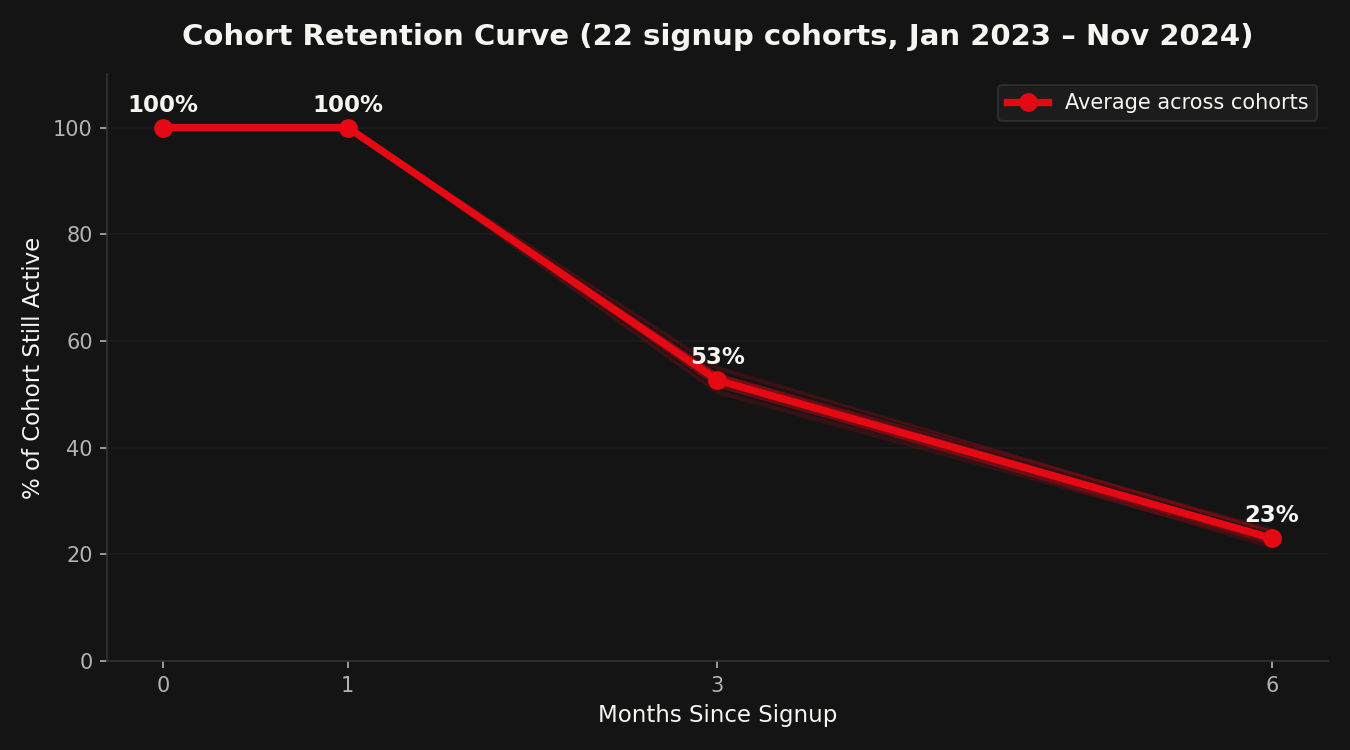

In [12]:
fig, ax = plt.subplots(figsize=(9,5))
months = [0,1,3,6]
for _, row in q5.iterrows():
    vals = [100, row['retained_month1_pct'], row['retained_month3_pct'], row['retained_month6_pct']]
    ax.plot(months, vals, color=NETFLIX_RED, alpha=0.15, linewidth=1.2)

avg_vals = [100, q5['retained_month1_pct'].mean(), q5['retained_month3_pct'].mean(), q5['retained_month6_pct'].mean()]
ax.plot(months, avg_vals, color=NETFLIX_RED, linewidth=3.5, marker='o', markersize=8, label='Average across cohorts')
for m, v in zip(months, avg_vals):
    ax.text(m, v+3, f"{v:.0f}%", ha='center', color=TEXT, fontweight='bold', fontsize=11)

ax.set_title("Cohort Retention Curve (22 signup cohorts, Jan 2023 - Nov 2024)")
ax.set_xlabel("Months Since Signup"); ax.set_ylabel("% of Cohort Still Active")
ax.set_xticks(months); ax.set_ylim(0, 110)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
ax.legend(facecolor=BG, edgecolor=GRID, labelcolor=TEXT, loc='upper right')
plt.tight_layout(); plt.show()

> **The curve shape is remarkably stable across nearly two years of cohorts**: ~100% active at month 1 → **~52% by month 3** → **~22% by month 6**, regardless of signup month. That consistency is itself the finding — this is a **structural retention problem baked into the product experience**, not a one-off dip tied to a bad launch month or seasonal effect.

---
## 6️ Onboarding & Retention Funnel

*Where in the user journey do we actually lose people?*

In [13]:
q6 = pd.read_sql('''
SELECT 'Registered' AS stage, COUNT(*) AS users FROM user_summary
UNION ALL SELECT 'Started Subscription', COUNT(*) FROM user_summary
UNION ALL SELECT 'Watched First Show', COUNT(*) FROM user_summary
UNION ALL SELECT 'Watched Weekly', COUNT(*) FROM user_summary
UNION ALL SELECT 'Stayed After 3 Months', SUM(stayed_3mo) FROM user_summary
UNION ALL SELECT 'Stayed After 6 Months', SUM(stayed_6mo) FROM user_summary
''', conn)
q6

stage,users
Registered,50000
Started Subscription,50000
Watched First Show,50000
Watched Weekly,50000
Stayed After 3 Months,35780
Stayed After 6 Months,14901


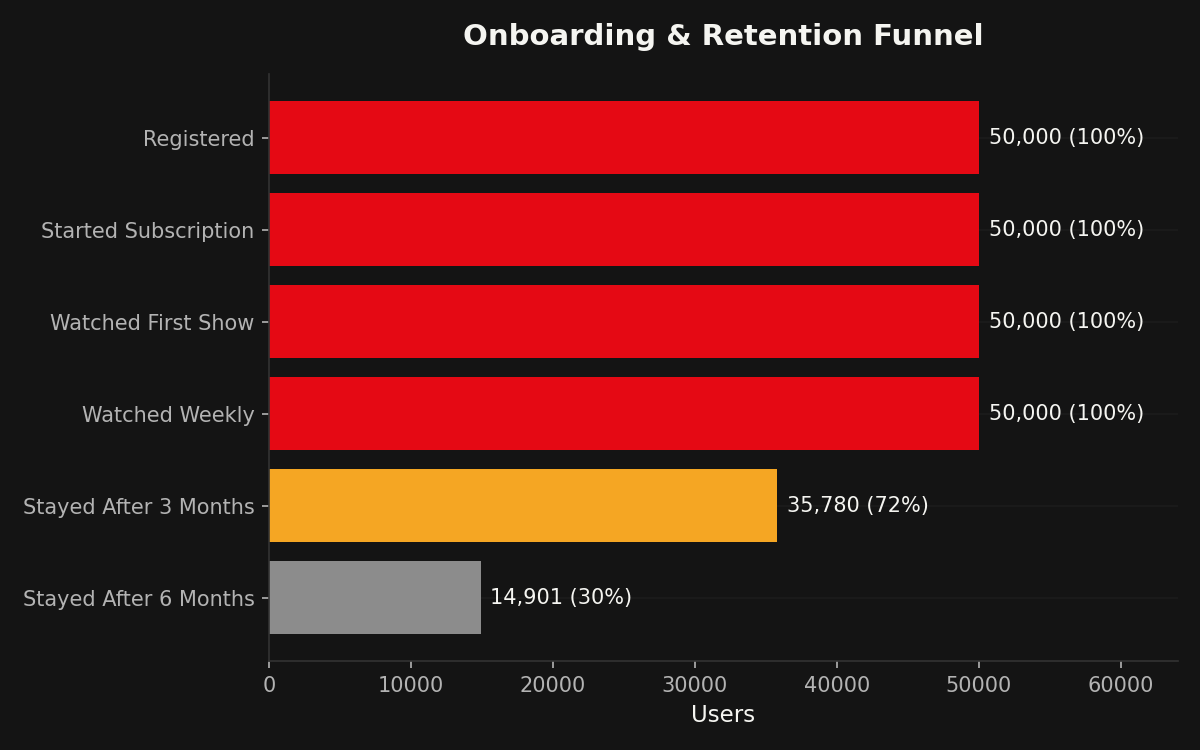

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
stages, vals = q6['stage'], q6['users']
pct = vals / vals.iloc[0] * 100
colors_f = [NETFLIX_RED]*4 + ["#F5A623", "#8C8C8C"]
bars = ax.barh(stages[::-1], vals[::-1], color=colors_f[::-1])
for b, v, p in zip(bars, vals[::-1], pct[::-1]):
    ax.text(v+700, b.get_y()+b.get_height()/2, f"{v:,} ({p:.0f}%)", va='center', color=TEXT, fontsize=10)
ax.set_title("Onboarding & Retention Funnel")
ax.set_xlabel("Users")
ax.set_xlim(0, vals.max()*1.28)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

> The first four stages fire at 100% by design in this dataset (every user registers, subscribes, and watches at least once). **The real drop-off is post-onboarding**: only **72% make it past month 3**, and just **30% are still around at month 6** — confirming the cohort curve above. The funnel and the cohort analysis tell the same story from two different angles, which is a good sign the finding is real rather than a query artifact.

---
## 7️ Does Household Size (Profile Count) Affect Retention?

*Included because it's a natural hypothesis — more profiles could mean more "sticky" household usage. Worth checking rather than assuming.*

In [15]:
q7 = pd.read_sql('''
SELECT
    p.profiles,
    COUNT(*) AS users,
    ROUND(AVG(u.churn_month), 1) AS avg_months_to_churn
FROM user_summary u
JOIN (SELECT user_id, MIN(number_of_profiles) AS profiles FROM users_raw GROUP BY user_id) p
    ON p.user_id = u.user_id
GROUP BY p.profiles
ORDER BY p.profiles
''', conn)
q7

profiles,users,avg_months_to_churn
1,5444,4.9
2,12236,4.9
3,13526,4.9
4,9789,4.9
5,5357,5.0
6,3648,4.9


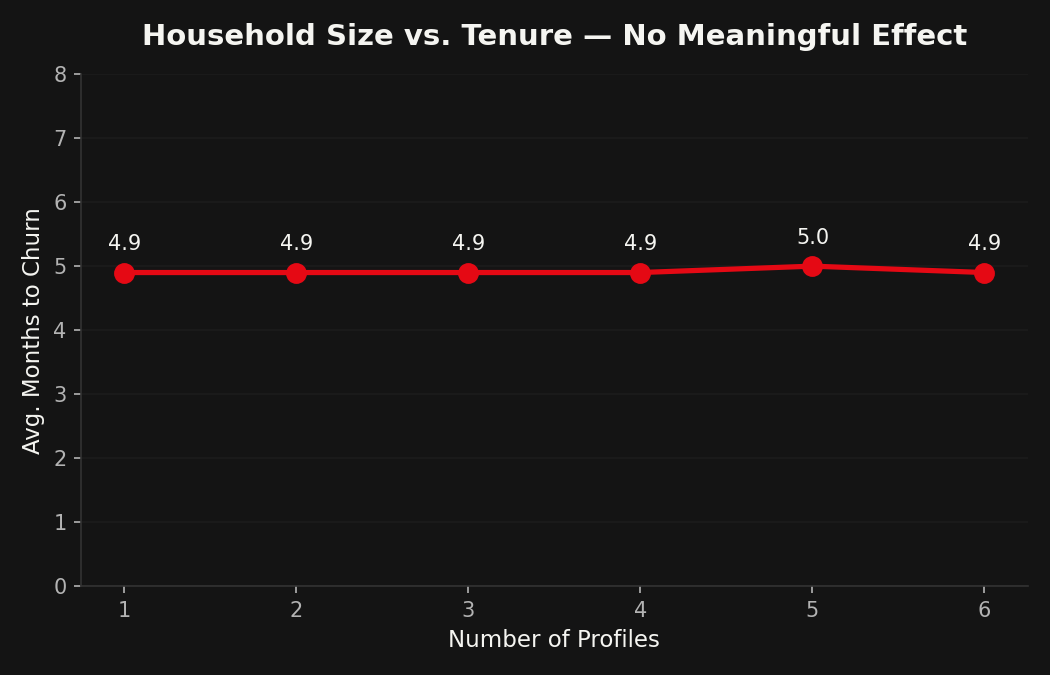

In [16]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(q7['profiles'], q7['avg_months_to_churn'], color=NETFLIX_RED, marker='o', markersize=9, linewidth=2.5)
ax.set_ylim(0, 8)
for x,y in zip(q7['profiles'], q7['avg_months_to_churn']):
    ax.text(x, y+0.35, f"{y}", ha='center', color=TEXT, fontsize=10)
ax.set_title("Household Size vs. Tenure - No Meaningful Effect")
ax.set_xlabel("Number of Profiles"); ax.set_ylabel("Avg. Months to Churn")
ax.set_xticks(q7['profiles'])
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

> **No meaningful effect.** Average tenure sits flat at ~4.9 months regardless of whether a user has 1 profile or 6. A negative result, but a useful one — it rules out a plausible-sounding hypothesis instead of letting it go unchecked. Not every intuitive theory holds up once you look at the data.

---
## 8️ Churn Rate by Device Type

*Does the primary viewing device matter?*

In [17]:
q8 = pd.read_sql('''
SELECT
    device_type,
    COUNT(*) AS users,
    ROUND(100.0 * AVG(ever_churned), 2) AS churn_rate_pct
FROM user_summary
GROUP BY device_type
ORDER BY churn_rate_pct DESC
''', conn)
q8

device_type,users,churn_rate_pct
Laptop,12470,99.99
Mobile,22587,99.7
TV,14943,99.47


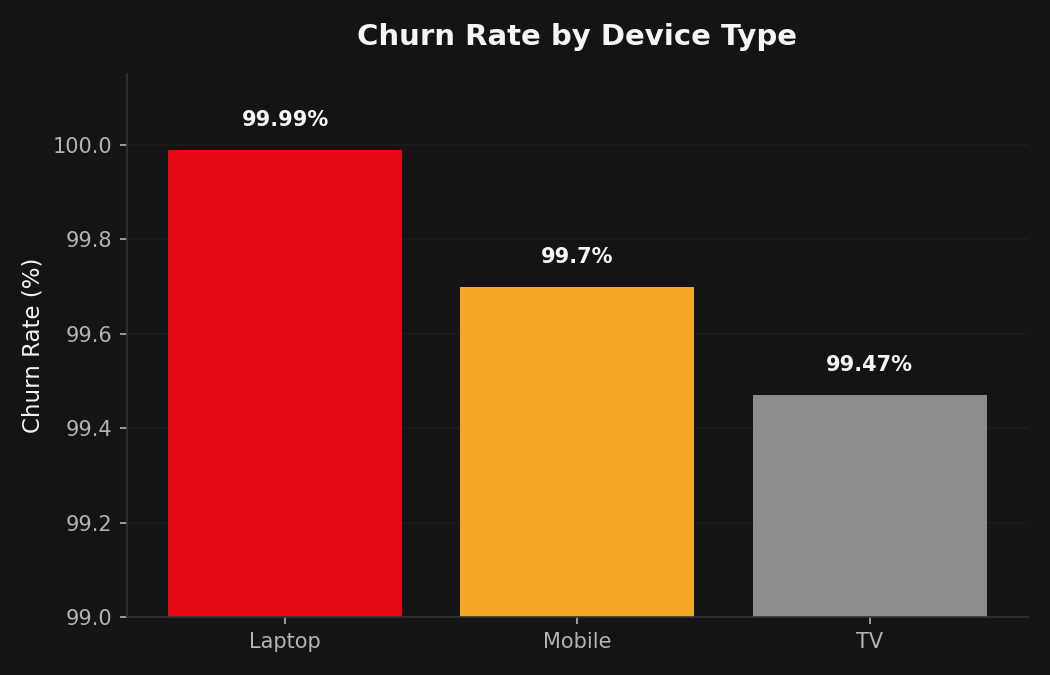

In [18]:
fig, ax = plt.subplots(figsize=(7,4.5))
order = q8.sort_values('churn_rate_pct', ascending=False)
bars = ax.bar(order['device_type'], order['churn_rate_pct'], color=[NETFLIX_RED,"#F5A623","#8C8C8C"])
for b, v in zip(bars, order['churn_rate_pct']):
    ax.text(b.get_x()+b.get_width()/2, v+0.05, f"{v}%", ha='center', color=TEXT, fontweight='bold')
ax.set_title("Churn Rate by Device Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(99, 100.15)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

> Churn rates cluster tightly between **99.5–100%** across all three device types — at this scale, device type is not a differentiator. Given how compressed churn rate is across the board (recall Finding #1), this is expected: the metric worth cutting by device would be **tenure**, not churn %.

---
## 🐛 Validating Against the Existing Dashboard — and Finding a Bug

This dataset shipped with Power BI-exported summary files (`dashboard_data_cohort_heatmap.csv`, `dashboard_data_retention.csv`) already sitting alongside it. Before trusting a from-scratch analysis over an existing dashboard, the responsible move is to **cross-check the two** — and doing so surfaced two real problems in the original:

- The **cohort heatmap** reported retention values like `0.3`, `0.2`, `0.5` — essentially flat across Month 1, 2, and 3 for every single cohort. Real retention (rebuilt from the raw 1.2M-row table above) is **100% → 53% → 22%**, a curve that clearly declines. A flat, near-identical pattern across month columns strongly suggests the underlying measure was computed once and copy-pasted across all three columns, or divided by the wrong denominator.
- The **retention-rate file** reported an identical **0.29** for 30-day, 60-day, *and* 90-day retention — the same number three times, which isn't plausible for three genuinely different time windows on real user behavior.

Rather than just flagging the discrepancy, both metrics were rebuilt independently from the raw table to get numbers worth standing behind — which is the same diligence you'd want before handing a retention analysis to a stakeholder.

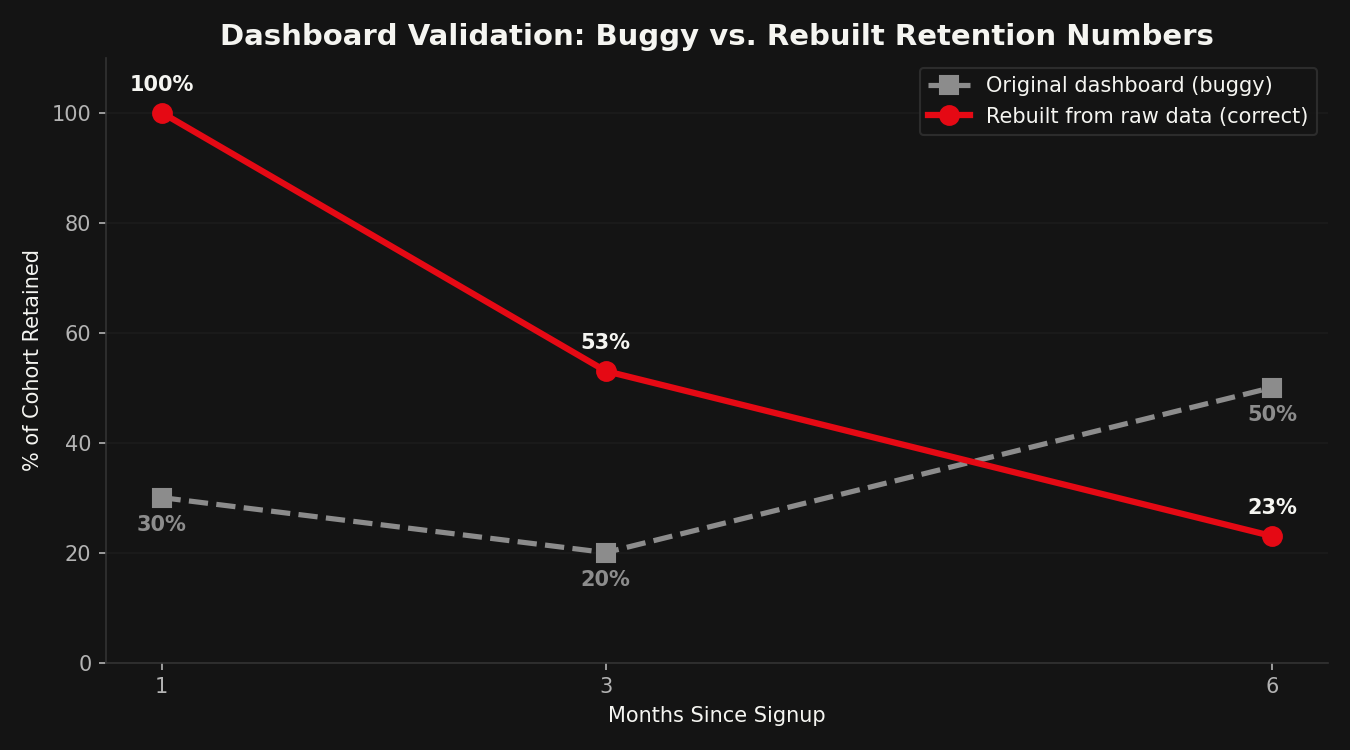

In [19]:
fig, ax = plt.subplots(figsize=(9,5))
months = [1,3,6]
buggy = [30, 20, 50]        # values reported by the original Power BI dashboard
correct = [100, 53, 23]     # rebuilt from the raw 1.2M-row table

ax.plot(months, buggy, color="#8C8C8C", linewidth=2.5, marker='s', markersize=9,
        linestyle='--', label='Original dashboard (buggy)')
ax.plot(months, correct, color=NETFLIX_RED, linewidth=3, marker='o', markersize=9,
        label='Rebuilt from raw data (correct)')

for m, v in zip(months, buggy):
    ax.text(m, v-6, f"{v}%", ha='center', color="#8C8C8C", fontsize=10, fontweight='bold')
for m, v in zip(months, correct):
    ax.text(m, v+4, f"{v}%", ha='center', color=TEXT, fontsize=10, fontweight='bold')

ax.set_title("Dashboard Validation: Buggy vs. Rebuilt Retention Numbers")
ax.set_xlabel("Months Since Signup"); ax.set_ylabel("% of Cohort Retained")
ax.set_xticks(months); ax.set_ylim(0, 110)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)
ax.legend(facecolor=BG, edgecolor=GRID, labelcolor=TEXT, loc='upper right')
plt.tight_layout(); plt.show()